# Etapa 1 — Limpieza, estandarización y definición de Mc

---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

In [27]:
ENCODING = 'latin-1'  

df_raw = pd.read_csv('SSNMX.csv', encoding=ENCODING, low_memory=False)

print(f'Filas cargadas: {len(df_raw):,}')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head(3)

Filas cargadas: 387,399
Columnas: ['Fecha', 'Hora', 'Magnitud', 'Latitud', 'Longitud', 'Profundidad', 'Referencia de localizacion', 'Fecha UTC', 'Hora UTC', 'Estatus']


,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,20/01/1900,00:33:30,7.4,20.0,-105.0,33.0,"71 km al NOROESTE de AUTLAN DE NAVARRO, JAL",20/01/1900,06:33:30,revisado
1,16/05/1900,14:12:00,6.9,20.0,-105.0,33.0,"71 km al NOROESTE de AUTLAN DE NAVARRO, JAL",16/05/1900,20:12:00,revisado
2,05/03/1901,04:45:00,6.9,25.0,-110.0,33.0,"100 km al NORESTE de LA PAZ, BCS",05/03/1901,10:45:00,revisado


Realizamos la corrección de tipado detectada en el notebook anterior: Magnitud a numérico

In [28]:
descartes = {}  # Acumulador del reporte de descartes

def snapshot(label, df):
    print(f'[{label}] → {len(df):,} registros')

snapshot('raw', df_raw)

df = df_raw.copy()

df['Magnitud'] = pd.to_numeric(df['Magnitud'], errors='coerce')

mag_no_num = df['Magnitud'].isna().sum()
descartes['magnitud_no_convertible'] = int(mag_no_num)
print(f'Registros con magnitud no convertible: {mag_no_num}')

df = df.dropna(subset=['Magnitud'])
snapshot('post-tipado', df)

[raw] → 387,399 registros
Registros con magnitud no convertible: 17649
[post-tipado] → 369,750 registros


Construimos un timestamp UTC canónico:

In [29]:
# Combinamos Fecha UTC + Hora UTC en un solo datetime timezone-aware
df['datetime_utc'] = pd.to_datetime(
    df['Fecha UTC'] + ' ' + df['Hora UTC'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce',
    utc=True
)

# Hora local para el filtro "hora del día" en el dashboard posterior
df['hora_local'] = pd.to_datetime(
    df['Fecha'] + ' ' + df['Hora'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
).dt.hour

ts_nulos = df['datetime_utc'].isna().sum()
descartes['timestamp_invalido'] = int(ts_nulos)
print(f'Timestamps no convertibles: {ts_nulos}')

df = df.dropna(subset=['datetime_utc'])
snapshot('post-datetime', df)

Timestamps no convertibles: 0
[post-datetime] → 369,750 registros


Realizamos una limpieza de texto y extracción de estado:

In [30]:
df['Referencia de localizacion'] = df['Referencia de localizacion'].str.strip()

# Extraer la abreviatura del estado (último token de 2-4 letras mayúsculas al final)
df['estado'] = (
    df['Referencia de localizacion']
    .str.extract(r',\s*([A-Z]{2,4})\s*$')[0]
)

print('Estados encontrados:')
print(df['estado'].value_counts().head(20))
print(f'\nRegistros sin estado extraído: {df["estado"].isna().sum():,}')

Estados encontrados:
estado
OAX     127396
GRO      66739
CHIS     59411
MICH     25482
BC       23096
BCS      20063
JAL      14217
COL      11899
VER       8041
SON       2813
PUE       1820
SIN       1474
HGO        933
ZAC        908
CHIH       740
SLP        704
MEX        681
NL         634
TAB        537
CDMX       503
Name: count, dtype: int64

Registros sin estado extraído: 3


A partir de los boxplots del EDA, nos percatamos de registros fuera del territorio nacional, por lo que usaremos las coordenadas del territorio mexicano para descartarlos.

In [31]:
LAT_MIN, LAT_MAX = 13.5, 33.5
LON_MIN, LON_MAX = -119.0, -85.5

fuera = ~(
    df['Latitud'].between(LAT_MIN, LAT_MAX) &
    df['Longitud'].between(LON_MIN, LON_MAX)
)
descartes['fuera_de_mexico'] = int(fuera.sum())
print(f'Registros fuera del bounding box México: {fuera.sum()}')

df = df[~fuera]
snapshot('post-filtro-geo', df)

Registros fuera del bounding box México: 718
[post-filtro-geo] → 369,032 registros


## Magnitud de completitud (Mc) variable por época

Se usa el **método de máxima curvatura**: la Mc es el pico de la distribución
de frecuencias (histograma) de magnitudes, que corresponde al punto de inflexión
de la curva acumulada de Gutenberg-Richter. Se aplica en ventanas de 2 años a lo largo del catálogo para capturar la
mejora progresiva de la red.

In [32]:
def mc_maxima_curvatura(magnitudes, bin_size=0.1):
    """Mc = valor de magnitud en el pico del histograma de frecuencias."""
    mag = magnitudes.dropna()
    bins = np.arange(mag.min(), mag.max() + bin_size, bin_size)
    counts, edges = np.histogram(mag, bins=bins)
    pico_idx = np.argmax(counts)
    return round(edges[pico_idx], 1)


VENTANA_AÑOS = 2
df['year'] = df['datetime_utc'].dt.year

años = sorted(df['year'].unique())
epocas = []

for inicio in range(años[0], años[-1] + 1, VENTANA_AÑOS):
    fin = inicio + VENTANA_AÑOS - 1
    mask = df['year'].between(inicio, fin)
    sub = df.loc[mask, 'Magnitud']
    if len(sub) < 100:  # ventana con muy pocos datos (p.ej. 2005 parcial)
        mc = None
    else:
        mc = mc_maxima_curvatura(sub)
    epocas.append({'epoca_inicio': inicio, 'epoca_fin': fin, 'n_sismos': len(sub), 'Mc': mc})

mc_tabla = pd.DataFrame(epocas)
display(mc_tabla)

,epoca_inicio,epoca_fin,n_sismos,Mc
0,1900,1901,4,NaN
1,1902,1903,5,NaN
2,1904,1905,2,NaN
3,1906,1907,3,NaN
4,1908,1909,7,NaN
...,...,...,...,...
59,2018,2019,56832,3.5
60,2020,2021,59095,3.6
61,2022,2023,53967,3.4
62,2024,2025,72562,3.4


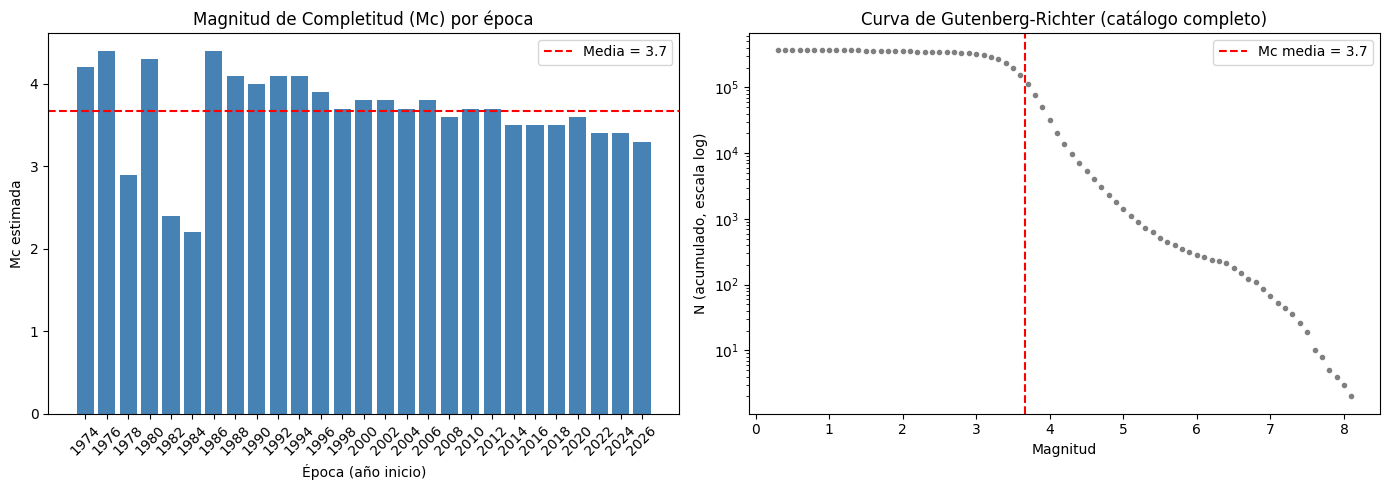

In [33]:
# Visualización de Mc por época sobre la distribución G-R global
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: Mc por época
mc_validas = mc_tabla.dropna(subset=['Mc'])
axes[0].bar(mc_validas['epoca_inicio'].astype(str), mc_validas['Mc'], color='steelblue')
axes[0].set_xlabel('Época (año inicio)')
axes[0].set_ylabel('Mc estimada')
axes[0].set_title('Magnitud de Completitud (Mc) por época')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(mc_validas['Mc'].mean(), color='red', linestyle='--', label=f'Media = {mc_validas["Mc"].mean():.1f}')
axes[0].legend()

# Derecha: distribución acumulada G-R global
mags = df['Magnitud'].dropna()
bin_size = 0.1
bins = np.arange(mags.min(), mags.max() + bin_size, bin_size)
counts, edges = np.histogram(mags, bins=bins)
cum_counts = counts[::-1].cumsum()[::-1]  # frecuencia acumulada descendente

axes[1].semilogy(edges[:-1], cum_counts, 'o', markersize=3, color='gray')
axes[1].set_xlabel('Magnitud')
axes[1].set_ylabel('N (acumulado, escala log)')
axes[1].set_title('Curva de Gutenberg-Richter (catálogo completo)')
if not mc_validas.empty:
    mc_media = mc_validas['Mc'].mean()
    axes[1].axvline(mc_media, color='red', linestyle='--', label=f'Mc media = {mc_media:.1f}')
    axes[1].legend()

plt.tight_layout()
plt.show()

La estimación de Mc requiere suficiente densidad de registros. El análisis por época muestra que antes de 1974 los datos son insuficientes para calcular una Mc confiable, por lo que descartamos esos registros.

In [34]:
ANIO_MINIMO = 1974

antes_de_1974 = df['datetime_utc'].dt.year < ANIO_MINIMO
descartes['antes_de_1974'] = int(antes_de_1974.sum())
print(f'Registros anteriores a {ANIO_MINIMO}: {antes_de_1974.sum():,}')

df = df[~antes_de_1974]
snapshot('post-filtro-año', df)

Registros anteriores a 1974: 137
[post-filtro-año] → 368,895 registros


Detectamos duplicados y columnas a descartar:

In [35]:
dupes = df.duplicated().sum()
descartes['duplicados'] = int(dupes)
print(f'Duplicados exactos: {dupes}')

df = df.drop_duplicates()

# Descartar columnas redundantes o de proceso
# Estatus es indistinto entre revisado/verificado, por lo que se descarta
# Fecha/Hora local quedan como hora_local (numérica); Fecha UTC / Hora UTC ya están en datetime_utc
cols_a_drop = ['Fecha', 'Hora', 'Fecha UTC', 'Hora UTC', 'Estatus']
df = df.drop(columns=cols_a_drop)

print(f'Columnas finales: {list(df.columns)}')
snapshot('post-dedup', df)

Duplicados exactos: 0
Columnas finales: ['Magnitud', 'Latitud', 'Longitud', 'Profundidad', 'Referencia de localizacion', 'datetime_utc', 'hora_local', 'estado', 'year']
[post-dedup] → 368,895 registros


In [36]:
total_raw = len(df_raw)
total_clean = len(df)

print('\t\tREPORTE DE DESCARTES')
print('-' * 50)
for motivo, n in descartes.items():
    print(f'{motivo:<35} {n:>6,}  ({n/total_raw*100:.2f}%)')
print('-' * 50)
print(f'  Registros originales: {total_raw:>6,}')
print(f'  Registros limpios: {total_clean:>6,}')
print(f'  Total descartado: {total_raw - total_clean:>6,}  ({(total_raw-total_clean)/total_raw*100:.2f}%)')

		REPORTE DE DESCARTES
--------------------------------------------------
magnitud_no_convertible             17,649  (4.56%)
timestamp_invalido                       0  (0.00%)
fuera_de_mexico                        718  (0.19%)
antes_de_1974                          137  (0.04%)
duplicados                               0  (0.00%)
--------------------------------------------------
  Registros originales: 387,399
  Registros limpios: 368,895
  Total descartado: 18,504  (4.78%)


Asignamos el Mc correspondiente a cada registro y añadimos una columna de época

In [37]:
# Mapeo año → Mc de su época
year_to_mc = {}
for _, row in mc_tabla.iterrows():
    for y in range(int(row['epoca_inicio']), int(row['epoca_fin']) + 1):
        year_to_mc[y] = row['Mc']

df['Mc_epoca'] = df['year'].map(year_to_mc)

# Columna booleana: ¿está este sismo por encima de la Mc de su época?
df['sobre_Mc'] = df['Magnitud'] >= df['Mc_epoca']

print(f'Sismos sobre Mc de su época: {df["sobre_Mc"].sum():,}')
print(f'Sismos bajo Mc (microsismos para análisis estadístico): {(~df["sobre_Mc"]).sum():,}')

Sismos sobre Mc de su época: 232,270
Sismos bajo Mc (microsismos para análisis estadístico): 136,625


In [38]:
# Dataset limpio completo (incluye todos los sismos con columna sobre_Mc)
df.to_parquet('seismos_clean.parquet', index=False)
print(f'Guardado: seismos_clean.parquet  ({Path("seismos_clean.parquet").stat().st_size / 1e6:.1f} MB)')

# Tabla de Mc por época
mc_tabla.to_csv('mc_por_epoca.csv', index=False)
print(f'Guardado: mc_por_epoca.csv')

Guardado: seismos_clean.parquet  (9.1 MB)
Guardado: mc_por_epoca.csv
